# DEF-D Fysieke Ontwerpopdracht 5 Invul template

## Groep informatie

Aan het einde van deze ontwerpopdracht lever je als groep één gezamenlijk notebook in. Zet jullie studienummers en namen in onderstaande tabel zodat wij zeker weten dat het groepsvormen goed is gegaan.

| Groep: 50     |  |
| :-------------|:-------------|
| Siemen Spek | 6579531 |
| Tije Kijlstra | 6448003 |
| Lieke Boontjes | 6543715 |

## Opdracht 1: Planning.

| Planning Groep: 50     |Tijdstip / Tijdspanne  | door wie  |
|---|---|---|
| Arduino testen| 11.15 | naam |
| ontwerp-eis berekenen| 11.30 | naam|
| Pauze 1| 12.45 - 13.45 | hele groep |
| iteratie 1 | 14.30 | hele groep |
| controleren en afvinken | 16.00 - 16.30 | hele groep |
| opruimen | 16.30 | hele groep |

Run onderstaande cel om alle benodigde libraries te laden. Mogelijk voeg je er zelf nog een aantal toe later vandaag. 

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import random
import time
import math

## Opdracht 2a: Opsplitsen taak 1: Arduino
Vul onderstaande tabel in:

| onderwerp    | antwoord  |
|---|---|
| hoe moeilijk (schaal 1 - 10) | 5 |
| hoe lang voor één meting | 5-10 min |
| verwacht nauwkeurigheid meting | 10% |

## Opdracht 2b: Opsplitsen taak 2: afleiding ontwerpeis

In [2]:

# Bereken hier je benodigde kantelfrequentie
grondfrequentie = 5*2*np.pi #Hz
kantelfrequentie =  5*np.pi

print(f"de maximale kantelfrequentie voor een demping met factor 3 is:{kantelfrequentie:.2f}")

de maximale kantelfrequentie voor een demping met factor 3 is:15.71


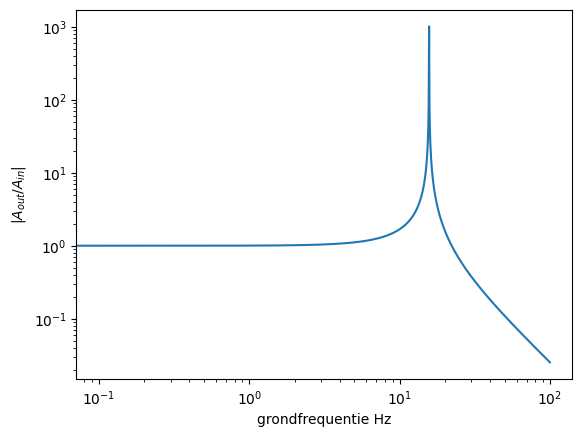

In [3]:
# Voeg hier je plot in.
def amplitudeverhouding(f0, f):
    return 1 / (1 - (f / f0)**2)

frequenties = np.linspace(0, 100, 1000)

plt.figure()
plt.plot(frequenties,np.abs(amplitudeverhouding(kantelfrequentie, frequenties)))
plt.xscale('log')
plt.yscale('log')
plt.xlabel('grondfrequentie Hz')
plt.ylabel(r'$|A_{out}/A_{in}|$')
plt.show()


In [4]:
# Bereken hier de minimale Delta-x waarbij je aan de eis van de opdracht voldoet.
g = 9.81 #m/s
dx = g/kantelfrequentie**2

print(dx)

0.039758432461253344


## Opdracht 3: Plot de grafiek.

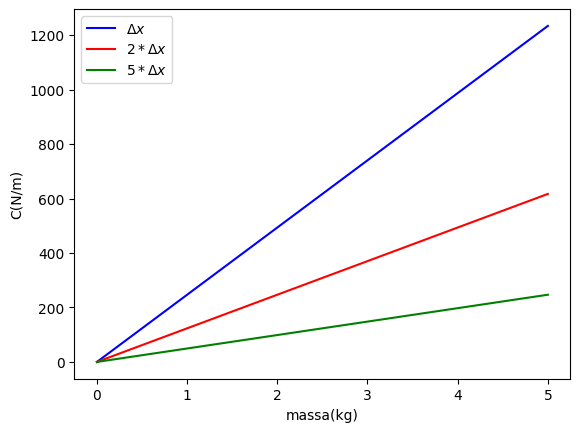

In [5]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().
m = np.linspace(0,5,300)
def function(delta_x):
    return m*g/delta_x


plt.figure()
plt.plot(m,function(dx),'b-', label = r'$\Delta{x}$')
plt.plot(m,function(2*dx),'r-', label = r'$2*\Delta{x}$')
plt.plot(m,function(5*dx),'g-', label = r'$5*\Delta{x}$')
plt.xlabel('massa(kg)')
plt.ylabel('C(N/m)')
plt.legend()
plt.show()

## Opdracht 4: Verander $\Delta x$.

We kunnen $\Delta x$ verhogen door:

- Door de m te verhogen
- Door de c te verlagen

Vul onderstaande aan. Geef eventueel met tekst aan waarom je hiervoor gekozen hebt, als extra informatie richting de nakijkers. 

Als groep gaan we mikken op een $\Delta x$ van: 5 cm

## Opdracht 5: Schets.

##### schets opstelling: 
<img src="schets_opstelling.jpeg" width="400">

## Opdracht 6: Beslissing evaluatie

Voldoet je ontwerp aan de eisen? Beantwoord de volgende vragen:

### Wat is de $\Delta x$ van je ontwerp?

5 centimeter

### Wordt die $\Delta x$ behaald met je gekozen massa en veer?

Ja

### hoeveel verder kan je massa-veer systeem nog uitrekken / indrukken?
Wat is de limiet aan je veer / verend materiaal voordat het niet meer lineair reageert volgens de wet van Hooke?

Een stuk of 20 centimeter.

### Is dat genoeg om straks metingen te kunnen doen?
Hou er rekening mee dat je trillingen een amplitude in de orde grote van een paar centimeter gaan hebben, minder is met deze opzet moeilijk te realiseren.

Ja

### Gaat je ontwerp dus voldoen aan de eis?

Ja

Als je hier positief geantwoord heb, maak dan nog een keer een plot van amplitude overdracht (y-as) versus frequentie (x-as) zoals je hierboven ook al een keer gedaan heb, maar plot nu twee verschillende overdrachten in de grafiek: één die je al had: behorende bij de grens van de ontwerp-eis en één behorende bij je eigen ontwerp. Lees af dat je voor je ontwerp daadwerkelijk onder de eis grafiek zit op de kritieke frequentie!

Deze grafiek heb je later weer nodig om je gemeten punten aan toe te voegen. Ga daarna je massa-veer systeem daadwerkelijk bouwen.

Als je hier negatief geantwoord hebt, kopieer onder deze cel dan alle cellen van Synthese tot en met Evaluation & decision en doorloop dat deel van het ontwerp proces nogmaals.

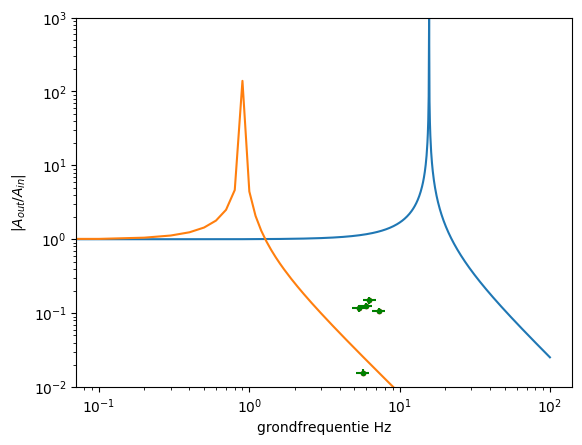

In [6]:
verhouding_a = np.array([0.5/4.62,0.74/4.95,0.09/5.71,0.75/6,0.73/6.24])
f_gemeten = np.array([7.3,6.3,5.7,6,5.4])

# verhouding_a = np.array([0.72/6.1,0.55/4.58,1.03/3.22,0.69/5.93,2.29/6.99,1.09/5.66,1.82/5.91,0.19/3.17])
# f_gemeten = np.array([5.75,5.7,5.3,5.2,3.9,3.85,3.9,2.8])


deltax = 12
omega_0 = np.sqrt(g/deltax)
a_verhouding = amplitudeverhouding(omega_0,frequenties)

# oude grafiek
plt.figure()
plt.plot(frequenties,np.abs(amplitudeverhouding(kantelfrequentie, frequenties)))
plt.plot(frequenties,np.abs(a_verhouding))
plt.plot(f_gemeten,verhouding_a,'r.')
plt.errorbar(f_gemeten,verhouding_a,0.1*verhouding_a,0.1*f_gemeten,'g.')
plt.xscale('log')
plt.yscale('log')
plt.ylim(10**-2,10**3)
plt.xlabel('grondfrequentie Hz')
plt.ylabel(r'$|A_{out}/A_{in}|$')
plt.show()


## Opdracht 7: Plotten maar

In [7]:
# Voeg hier je plots in.

Conclusie:  
De datapunten liggen te ver van de verwachtte grafiek af omdat onze sensor ook bewegingen in de x en de y richtingen heeft.

## Opdracht 8: Leerdoelen
Voeg hieronder zelf kopjes toe om aan te geven wat bij welk leerdoel hoort. 

## Leerdoel 1:

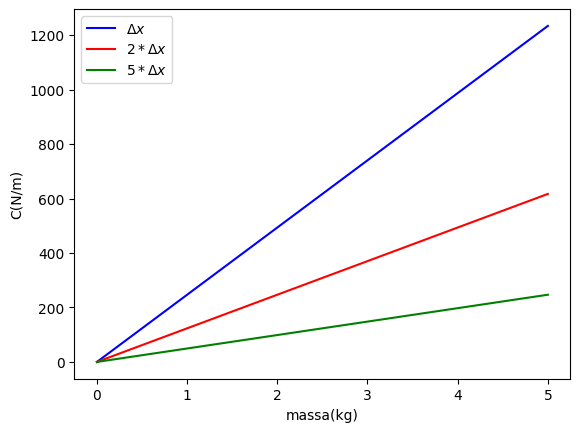

In [8]:
# Voeg hier je plot in. Lees goed de opdracht wat er in de grafiek moet staan!
# Het is ook handig om je grafiek op te slaan, doe dat door met plt.savefig().
m = np.linspace(0,5,300)
def function(delta_x):
    return m*g/delta_x


plt.figure()
plt.plot(m,function(dx),'b-', label = r'$\Delta{x}$')
plt.plot(m,function(2*dx),'r-', label = r'$2*\Delta{x}$')
plt.plot(m,function(5*dx),'g-', label = r'$5*\Delta{x}$')
plt.xlabel('massa(kg)')
plt.ylabel('C(N/m)')
plt.legend()
plt.show()

## Leerdoel 2:

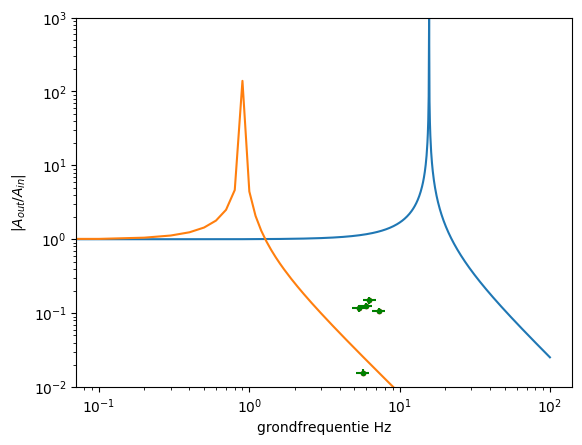

In [9]:
verhouding_a = np.array([0.5/4.62,0.74/4.95,0.09/5.71,0.75/6,0.73/6.24])
f_gemeten = np.array([7.3,6.3,5.7,6,5.4])

# verhouding_a = np.array([0.72/6.1,0.55/4.58,1.03/3.22,0.69/5.93,2.29/6.99,1.09/5.66,1.82/5.91,0.19/3.17])
# f_gemeten = np.array([5.75,5.7,5.3,5.2,3.9,3.85,3.9,2.8])


deltax = 12
omega_0 = np.sqrt(g/deltax)
a_verhouding = amplitudeverhouding(omega_0,frequenties)

# oude grafiek
plt.figure()
plt.plot(frequenties,np.abs(amplitudeverhouding(kantelfrequentie, frequenties)))
plt.plot(frequenties,np.abs(a_verhouding))
plt.plot(f_gemeten,verhouding_a,'r.')
plt.errorbar(f_gemeten,verhouding_a,0.1*verhouding_a,0.1*f_gemeten,'g.')
plt.xscale('log')
plt.yscale('log')
plt.ylim(10**-2,10**3)
plt.xlabel('grondfrequentie Hz')
plt.ylabel(r'$|A_{out}/A_{in}|$')
plt.show()
